# 분석 환경 설정하기

In [ ]:
# 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
!pip install koreanize_matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 50.6 MB/s eta 0:00:00


In [ ]:
import koreanize_matplotlib

# [1] 데이터 불러오기

- 테이블간 관계부터 확인

In [ ]:
# 데이터 불러오기
orders_df = pd.read_csv("/content/orders.csv")
pizza_types_df = pd.read_csv("/content/pizza_types.csv")
pizzas_df = pd.read_csv("/content/pizzas.csv")

In [ ]:
# 상위 5개 확인
orders_df.head()

,order_id,order_timestamp,order_details_id,pizza_id,quantity
0,1,2023-01-01 11:45:11,1,hawaiian_m,1
1,2,2023-01-01 11:53:26,2,big_meat_l,1
2,2,2023-01-01 11:53:26,3,classic_dlx_m,1
3,2,2023-01-01 11:53:26,4,five_cheese_l,1
4,2,2023-01-01 11:53:26,5,potato_m,1


In [ ]:
orders_df['order_details_id'].count(), orders_df['order_details_id'].nunique()

(np.int64(47079), 47079)

In [ ]:
orders_df['order_details_id'].isna().sum()

np.int64(0)

In [ ]:
# 상위 5개 확인
pizza_types_df.head()

,pizza_name,category,ingredients
0,바비큐 치킨 피자,치킨,"치킨, 피망, 토마토, 적양파, 바비큐 소스"
1,타이 치킨 피자,치킨,"치킨, 파인애플, 토마토, 피망, 타이 칠리 소스"
2,빅 미트 피자,클래식,"베이컨, 토마토, 페퍼로니, 살라미, 초리조"
3,클래식 디럭스 피자,클래식,"토마토, 페퍼로니, 버섯, 적양파, 피망, 베이컨"
4,슈퍼 슈프림 피자,클래식,"페퍼로니, 토마토, 적양파, 그린 올리브, 옥수수, 마늘"


In [ ]:
pizza_types_df['pizza_name'].count(), pizza_types_df['pizza_name'].nunique()

(np.int64(13), 13)

In [ ]:
pizza_types_df['pizza_name'].isna().sum()

np.int64(0)

In [ ]:
# 상위 5개 확인
pizzas_df.head()

,pizza_id,pizza_name,size,price
0,bbq_ckn_s,바비큐 치킨 피자,S,11300
1,bbq_ckn_m,바비큐 치킨 피자,M,22000
2,bbq_ckn_l,바비큐 치킨 피자,L,34000
3,thai_ckn_s,타이 치킨 피자,S,12300
4,thai_ckn_m,타이 치킨 피자,M,24000


In [ ]:
pizzas_df['pizza_id'].count(), pizzas_df['pizza_id'].nunique()

(np.int64(39), 39)

In [ ]:
pizzas_df['pizza_id'].isna().sum()

np.int64(0)

# [2] 데이터 전처리하기

In [ ]:
# 테이블의 행열 수 확인
print(orders_df.shape)
print(pizzas_df.shape)
print(pizza_types_df.shape)

(47079, 5)
(39, 4)
(13, 3)


In [ ]:
# 중복값 확인
print(orders_df.duplicated().sum())
print(pizzas_df.duplicated().sum())
print(pizza_types_df.duplicated().sum())

0
0
0


In [ ]:
# 결측치 확인
print(orders_df.isna().sum().sum())
print(pizzas_df.isna().sum().sum())
print(pizza_types_df.isna().sum().sum())

0
0
0


In [ ]:
# 이상치 파악
orders_df

,order_id,order_timestamp,order_details_id,pizza_id,quantity
0,1,2023-01-01 11:45:11,1,hawaiian_m,1
1,2,2023-01-01 11:53:26,2,big_meat_l,1
2,2,2023-01-01 11:53:26,3,classic_dlx_m,1
3,2,2023-01-01 11:53:26,4,five_cheese_l,1
4,2,2023-01-01 11:53:26,5,potato_m,1
...,...,...,...,...,...
47074,21348,2023-12-31 20:37:13,47075,bulgogi_m,1
47075,21348,2023-12-31 20:37:13,47076,potato_l,1
47076,21348,2023-12-31 20:37:13,47077,super_supreme_s,1
47077,21349,2023-12-31 21:02:45,47078,bulgogi_l,1


<Axes: ylabel='quantity'>

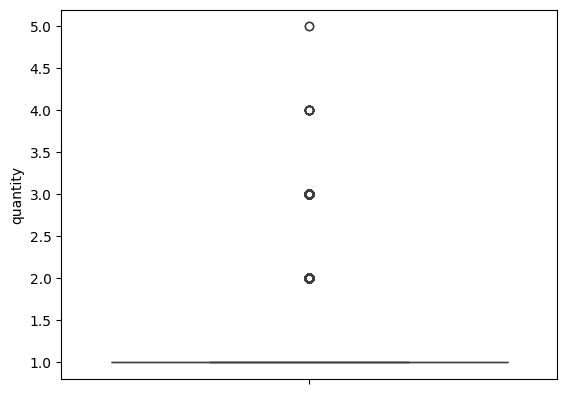

In [ ]:
# 이상치 파악 orders_df - quantity
sns.boxplot(orders_df['quantity'])

In [ ]:
# 피자 판매수량 별 주문 건수 비율
orders_df['quantity'].value_counts(normalize=True)

,proportion
quantity,
1,0.950870
2,0.045625
3,0.003186
4,0.000276
5,0.000042


<Axes: ylabel='price'>

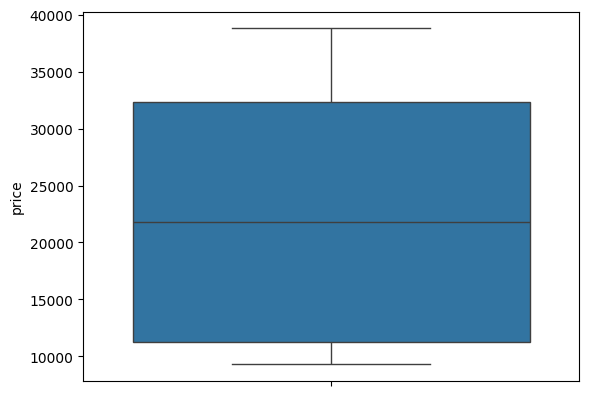

In [ ]:
# 이상치 파악 pizzas_df - price
sns.boxplot(pizzas_df['price'])

In [ ]:
# 데이터 결합하기 (두 개)
merge_order_pizza = pd.merge(orders_df, pizzas_df, on='pizza_id', how='left')

In [ ]:
merge_order_pizza.head()

,order_id,order_timestamp,order_details_id,pizza_id,quantity,pizza_name,size,price
0,1,2023-01-01 11:45:11,1,hawaiian_m,1,하와이안 피자,M,21800
1,2,2023-01-01 11:53:26,2,big_meat_l,1,빅 미트 피자,L,34000
2,2,2023-01-01 11:53:26,3,classic_dlx_m,1,클래식 디럭스 피자,M,20300
3,2,2023-01-01 11:53:26,4,five_cheese_l,1,파이브 치즈 피자,L,31000
4,2,2023-01-01 11:53:26,5,potato_m,1,포테이토 피자,M,21800


In [ ]:
merge_order_pizza.shape

(47079, 8)

In [ ]:
# 데이터 결합하기 (세 개)
pizza_orders_df = pd.merge(merge_order_pizza,pizza_types_df, on='pizza_name', how='left')

In [ ]:
pizza_orders_df.head()

,order_id,order_timestamp,order_details_id,pizza_id,quantity,pizza_name,size,price,category,ingredients
0,1,2023-01-01 11:45:11,1,hawaiian_m,1,하와이안 피자,M,21800,스페셜,"토마토, 베이컨, 파인애플, 모짜렐라 치즈"
1,2,2023-01-01 11:53:26,2,big_meat_l,1,빅 미트 피자,L,34000,클래식,"베이컨, 토마토, 페퍼로니, 살라미, 초리조"
2,2,2023-01-01 11:53:26,3,classic_dlx_m,1,클래식 디럭스 피자,M,20300,클래식,"토마토, 페퍼로니, 버섯, 적양파, 피망, 베이컨"
3,2,2023-01-01 11:53:26,4,five_cheese_l,1,파이브 치즈 피자,L,31000,베지테리언,"모짜렐라 치즈, 프로볼로네 치즈, 고다 치즈, 페코리노 치즈, 고르곤졸라 치즈"
4,2,2023-01-01 11:53:26,5,potato_m,1,포테이토 피자,M,21800,스페셜,"모짜렐라 치즈, 토마토, 감자, 양파, 베이컨, 옥수수, 마요네즈"


In [ ]:
pizza_orders_df.shape

(47079, 10)

In [ ]:
# 결측치 확인하기
pizza_orders_df.isna().sum().sum()

np.int64(0)

In [ ]:
# sales 칼럼 생성하기
pizza_orders_df['sales'] = pizza_orders_df['quantity'] * pizza_orders_df['price']

In [ ]:
pizza_orders_df.head()

,order_id,order_timestamp,order_details_id,pizza_id,quantity,pizza_name,size,price,category,ingredients,sales
0,1,2023-01-01 11:45:11,1,hawaiian_m,1,하와이안 피자,M,21800,스페셜,"토마토, 베이컨, 파인애플, 모짜렐라 치즈",21800
1,2,2023-01-01 11:53:26,2,big_meat_l,1,빅 미트 피자,L,34000,클래식,"베이컨, 토마토, 페퍼로니, 살라미, 초리조",34000
2,2,2023-01-01 11:53:26,3,classic_dlx_m,1,클래식 디럭스 피자,M,20300,클래식,"토마토, 페퍼로니, 버섯, 적양파, 피망, 베이컨",20300
3,2,2023-01-01 11:53:26,4,five_cheese_l,1,파이브 치즈 피자,L,31000,베지테리언,"모짜렐라 치즈, 프로볼로네 치즈, 고다 치즈, 페코리노 치즈, 고르곤졸라 치즈",31000
4,2,2023-01-01 11:53:26,5,potato_m,1,포테이토 피자,M,21800,스페셜,"모짜렐라 치즈, 토마토, 감자, 양파, 베이컨, 옥수수, 마요네즈",21800


# [3] 데이터 탐색하기

In [ ]:
pizza_orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47079 entries, 0 to 47078
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   order_id          47079 non-null  int64 
 1   order_timestamp   47079 non-null  object
 2   order_details_id  47079 non-null  int64 
 3   pizza_id          47079 non-null  object
 4   quantity          47079 non-null  int64 
 5   pizza_name        47079 non-null  object
 6   size              47079 non-null  object
 7   price             47079 non-null  int64 
 8   category          47079 non-null  object
 9   ingredients       47079 non-null  object
 10  sales             47079 non-null  int64 
dtypes: int64(5), object(6)
memory usage: 4.0+ MB


In [ ]:
# 날짜 데이터로 변환하기 (문자로 하면 날짜 추출이 어려움)
pizza_orders_df['order_timestamp'] = pd.to_datetime(pizza_orders_df['order_timestamp'])

In [ ]:
# 첫 주문 일시와 마지막 주문 일시 확인 (날짜 분류 기준 세우기 위해서)
print(pizza_orders_df['order_timestamp'].min())
print(pizza_orders_df['order_timestamp'].max())

2023-01-01 11:45:11
2023-12-31 21:56:56


In [ ]:
# 월
pizza_orders_df['month'] = pizza_orders_df['order_timestamp'].dt.month

# 요일
pizza_orders_df['day_name'] = pizza_orders_df['order_timestamp'].dt.day_name()
pizza_orders_df['dayofweek'] = pizza_orders_df['order_timestamp'].dt.dayofweek

# 시간
pizza_orders_df['hour'] = pizza_orders_df['order_timestamp'].dt.hour

In [ ]:
pizza_orders_df['dayofweek'].unique()

array([6, 0, 1, 2, 3, 4, 5], dtype=int32)

In [ ]:
# 평일/주말 구분 칼럼 생성하기
pizza_orders_df['type_of_day'] = np.where(pizza_orders_df['dayofweek']>=5, '주말', '평일')

In [ ]:
pizza_orders_df.head()

,order_id,order_timestamp,order_details_id,pizza_id,quantity,pizza_name,size,price,category,ingredients,sales,month,day_name,dayofweek,hour,type_of_day
0,1,2023-01-01 11:45:11,1,hawaiian_m,1,하와이안 피자,M,21800,스페셜,"토마토, 베이컨, 파인애플, 모짜렐라 치즈",21800,1,Sunday,6,11,주말
1,2,2023-01-01 11:53:26,2,big_meat_l,1,빅 미트 피자,L,34000,클래식,"베이컨, 토마토, 페퍼로니, 살라미, 초리조",34000,1,Sunday,6,11,주말
2,2,2023-01-01 11:53:26,3,classic_dlx_m,1,클래식 디럭스 피자,M,20300,클래식,"토마토, 페퍼로니, 버섯, 적양파, 피망, 베이컨",20300,1,Sunday,6,11,주말
3,2,2023-01-01 11:53:26,4,five_cheese_l,1,파이브 치즈 피자,L,31000,베지테리언,"모짜렐라 치즈, 프로볼로네 치즈, 고다 치즈, 페코리노 치즈, 고르곤졸라 치즈",31000,1,Sunday,6,11,주말
4,2,2023-01-01 11:53:26,5,potato_m,1,포테이토 피자,M,21800,스페셜,"모짜렐라 치즈, 토마토, 감자, 양파, 베이컨, 옥수수, 마요네즈",21800,1,Sunday,6,11,주말


In [ ]:
# 범주형 칼럼의 범주 개수와 종류 이해하기
cat_cols = ['pizza_name','size','category']
for col in cat_cols:
    print("="*50)
    print(col)
    print('범주의 개수: ', pizza_orders_df[col].nunique())
    print('범주의 종류: ', pizza_orders_df[col].unique())

pizza_name
범주의 개수:  13
범주의 종류:  ['하와이안 피자' '빅 미트 피자' '클래식 디럭스 피자' '파이브 치즈 피자' '포테이토 피자' '타이 치킨 피자'
 '페퍼로니 피자' '슈퍼 슈프림 피자' '바비큐 치킨 피자' '프로슈토 루꼴라 피자' '그린 가든 피자' '시금치 페스토 피자'
 '불고기 피자']
size
범주의 개수:  3
범주의 종류:  ['M' 'L' 'S']
category
범주의 개수:  4
범주의 종류:  ['스페셜' '클래식' '베지테리언' '치킨']


In [ ]:
pizza_orders_df[['category','pizza_name']].drop_duplicates().sort_values(by='category')

,category,pizza_name
3,베지테리언,파이브 치즈 피자
16,베지테리언,그린 가든 피자
19,베지테리언,시금치 페스토 피자
0,스페셜,하와이안 피자
4,스페셜,포테이토 피자
11,스페셜,프로슈토 루꼴라 피자
28,스페셜,불고기 피자
5,치킨,타이 치킨 피자
10,치킨,바비큐 치킨 피자
1,클래식,빅 미트 피자


# [4] 인사이트 도출하기

In [ ]:
pizza_orders_df.head()

,order_id,order_timestamp,order_details_id,pizza_id,quantity,pizza_name,size,price,category,ingredients,sales,month,day_name,dayofweek,hour,type_of_day
0,1,2023-01-01 11:45:11,1,hawaiian_m,1,하와이안 피자,M,21800,스페셜,"토마토, 베이컨, 파인애플, 모짜렐라 치즈",21800,1,Sunday,6,11,주말
1,2,2023-01-01 11:53:26,2,big_meat_l,1,빅 미트 피자,L,34000,클래식,"베이컨, 토마토, 페퍼로니, 살라미, 초리조",34000,1,Sunday,6,11,주말
2,2,2023-01-01 11:53:26,3,classic_dlx_m,1,클래식 디럭스 피자,M,20300,클래식,"토마토, 페퍼로니, 버섯, 적양파, 피망, 베이컨",20300,1,Sunday,6,11,주말
3,2,2023-01-01 11:53:26,4,five_cheese_l,1,파이브 치즈 피자,L,31000,베지테리언,"모짜렐라 치즈, 프로볼로네 치즈, 고다 치즈, 페코리노 치즈, 고르곤졸라 치즈",31000,1,Sunday,6,11,주말
4,2,2023-01-01 11:53:26,5,potato_m,1,포테이토 피자,M,21800,스페셜,"모짜렐라 치즈, 토마토, 감자, 양파, 베이컨, 옥수수, 마요네즈",21800,1,Sunday,6,11,주말


In [ ]:
# 칼럼명 확인하기 (큰 그림에서 그룹화 할 수 있으면 좋음)
pizza_orders_df.columns

Index(['order_id', 'order_timestamp', 'order_details_id', 'pizza_id',
       'quantity', 'pizza_name', 'size', 'price', 'category', 'ingredients',
       'sales', 'month', 'day_name', 'dayofweek', 'hour', 'type_of_day'],
      dtype='object')

In [ ]:
- 시간 관련 칼럼들:'order_timestamp', 'month', 'day_name', 'dayofweek', 'hour','type_of_day'
- 피자 카테고리/메뉴 관련 칼럼들: 'category', 'pizza_name', 'size', 'ingredients'

SyntaxError: invalid syntax (674818855.py, line 1)

## (1) 종합 결산

In [ ]:
# 2023년 총 영업일 수
total_days = pizza_orders_df['order_timestamp'].dt.date.nunique()
total_days

358

In [ ]:
# 2023년 총 주문 횟수
total_orders = pizza_orders_df['order_id'].nunique()
total_orders

21350

In [ ]:
# 일 평균 주문 건수
total_orders / total_days

59.63687150837989

In [ ]:
# 2023년 총 매출 (약 11억)
total_sales = pizza_orders_df['sales'].sum()
total_sales

np.int64(1140882200)

In [ ]:
# 일 평균 매출 (약 300만원)
sales_per_day = total_sales / total_days
sales_per_day

np.float64(3186821.7877094974)

In [ ]:
# 주문당 매출
sales_per_order = total_sales / total_orders
sales_per_order

np.float64(53437.105386416864)

In [ ]:
# 2023년 판매량
total_quantity = pizza_orders_df['quantity'].sum()
total_quantity

np.int64(49574)

In [ ]:
# 일 평균 판매량
total_quantity / total_days

np.float64(138.47486033519553)

## (2) 시간에 따른 매출

In [ ]:
pizza_orders_df.head(1)

,order_id,order_timestamp,order_details_id,pizza_id,quantity,pizza_name,size,price,category,ingredients,sales,month,day_name,dayofweek,hour,type_of_day
0,1,2023-01-01 11:45:11,1,hawaiian_m,1,하와이안 피자,M,21800,스페셜,"토마토, 베이컨, 파인애플, 모짜렐라 치즈",21800,1,Sunday,6,11,주말


### 월별 매출

In [ ]:
# 월별 매출 집계
sales_by_month = pizza_orders_df.groupby('month',as_index=False)['sales'].sum()
sales_by_month

,month,sales
0,1,93718700
1,2,89392300
2,3,98494600
3,4,96277400
4,5,100225300
5,6,95518100
6,7,101553600
7,8,94873600
8,9,89302500
9,10,88423800


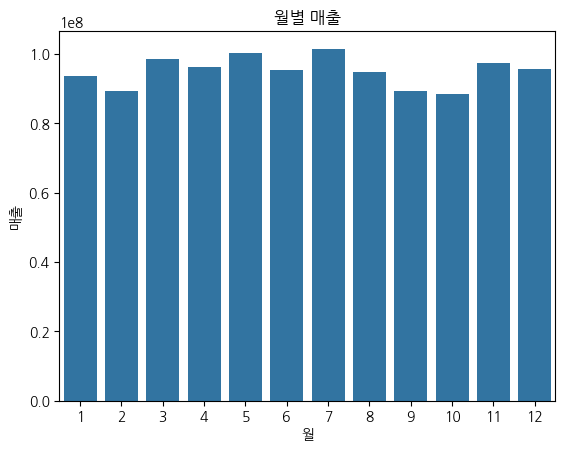

In [ ]:
sns.barplot(data=sales_by_month,x='month',y='sales')
plt.title('월별 매출')
plt.xlabel('월')
plt.ylabel('매출')
plt.show()

### 요일별 매출

In [ ]:
pizza_orders_df.head(1)

,order_id,order_timestamp,order_details_id,pizza_id,quantity,pizza_name,size,price,category,ingredients,sales,month,day_name,dayofweek,hour,type_of_day
0,1,2023-01-01 11:45:11,1,hawaiian_m,1,하와이안 피자,M,21800,스페셜,"토마토, 베이컨, 파인애플, 모짜렐라 치즈",21800,1,Sunday,6,11,주말


In [ ]:
sales_by_day_name = pizza_orders_df.groupby('day_name',as_index=False)['sales'].sum()
sales_by_day_name

,day_name,sales
0,Friday,185106800
1,Monday,147541300
2,Saturday,169516300
3,Sunday,143080900
4,Thursday,168921600
5,Tuesday,160866900
6,Wednesday,165848400


In [ ]:
sales_by_day_name['day_name'].unique()

array(['Friday', 'Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday',
       'Wednesday'], dtype=object)

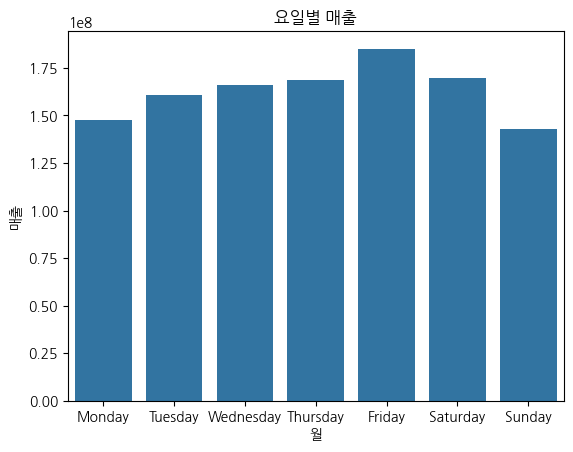

In [ ]:
sns.barplot(data=sales_by_day_name,x='day_name',y='sales',order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday', 'Sunday'])
plt.title('요일별 매출')
plt.xlabel('월')
plt.ylabel('매출')
plt.show()

- 금요일 매출이 가장 높았고, 상대적으로 일요일과 월요일 매출은 저조한 편임을 알 수 있다.

### 시간대별 매출

In [ ]:
pizza_orders_df.head(1)

,order_id,order_timestamp,order_details_id,pizza_id,quantity,pizza_name,size,price,category,ingredients,sales,month,day_name,dayofweek,hour,type_of_day
0,1,2023-01-01 11:45:11,1,hawaiian_m,1,하와이안 피자,M,21800,스페셜,"토마토, 베이컨, 파인애플, 모짜렐라 치즈",21800,1,Sunday,6,11,주말


In [ ]:
sales_by_hour = pizza_orders_df.groupby('hour',as_index=False)['sales'].sum()
sales_by_hour

,hour,sales
0,10,461000
1,11,64896300
2,12,131185900
3,13,140566100
4,14,82838800
5,15,81688100
6,16,106494800
7,17,122837100
8,18,124612100
9,19,102778400


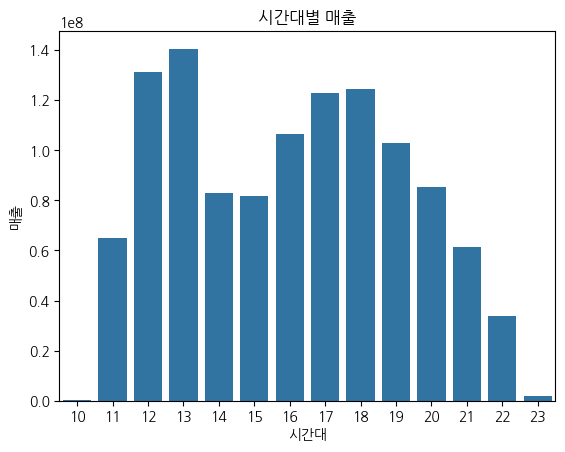

In [ ]:
sns.barplot(data=sales_by_hour,x='hour',y='sales')
plt.title('시간대별 매출')
plt.xlabel('시간대')
plt.ylabel('매출')
plt.show()

- 점심과 저녁 식사 시간대에 매출이 집중된 편이다. 따라서, 그만큼 처리해야할 주문이 많을 테니 인력이 부족하지 않도록 신경을 써야할 것이다.
- 애매한 오후 시간대나 밤 시간대에 매출이 다소 아쉬운 상황이므로 이런 시간대에는 할인 혜책이나 서비스 메뉴를 제공하는 식으로 매출 상승 유도를 고려해볼 수 있다. 피자라는 메뉴 특성을 살려 야식 고객을 더 늘릴 수 있다면 매출이 도움이 될 것이다.

### 평일과 주말의 시간대별 매출

In [ ]:
pizza_orders_df.head(1)

,order_id,order_timestamp,order_details_id,pizza_id,quantity,pizza_name,size,price,category,ingredients,sales,month,day_name,dayofweek,hour,type_of_day
0,1,2023-01-01 11:45:11,1,hawaiian_m,1,하와이안 피자,M,21800,스페셜,"토마토, 베이컨, 파인애플, 모짜렐라 치즈",21800,1,Sunday,6,11,주말


In [ ]:
# 평일/주말별 시간대별 총 매출 집계
sales_by_day_hour = pizza_orders_df.groupby(['type_of_day','hour'],as_index=False)['sales'].sum()
sales_by_day_hour.head()

,type_of_day,hour,sales
0,주말,10,100900
1,주말,11,11228800
2,주말,12,22257900
3,주말,13,28416200
4,주말,14,26884100


In [ ]:
# 평일 데이터
weekday_data = sales_by_day_hour.query("type_of_day == '평일'")

In [ ]:
# 주말 데이터
weekend_data = sales_by_day_hour.query("type_of_day == '주말'")

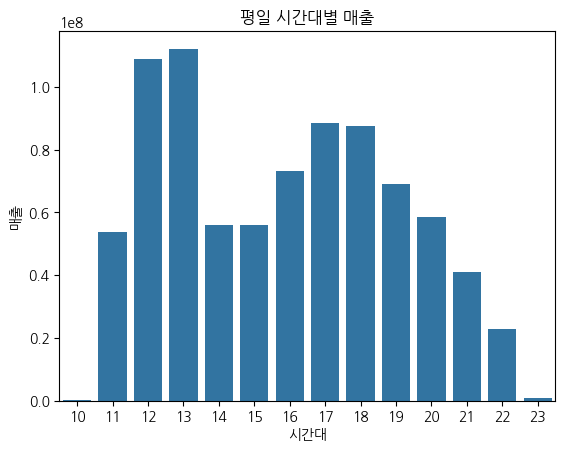

In [ ]:
# 평일 시간대별 매출 시각화
sns.barplot(data=weekday_data,x='hour',y='sales')
plt.title('평일 시간대별 매출')
plt.xlabel('시간대')
plt.ylabel('매출')
plt.show()

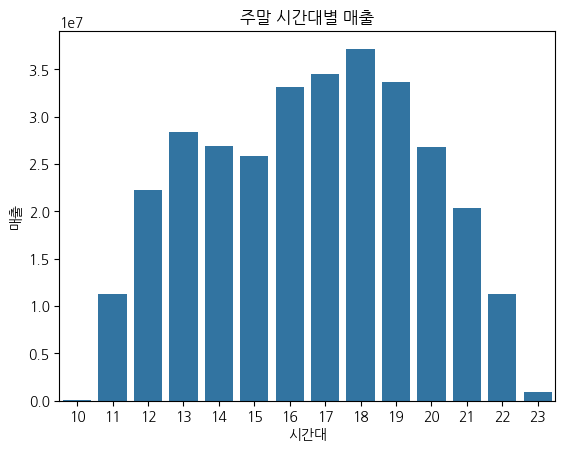

In [ ]:
# 주말 시간대별 매출 시각화
sns.barplot(data=weekend_data,x='hour',y='sales')
plt.title('주말 시간대별 매출')
plt.xlabel('시간대')
plt.ylabel('매출')
plt.show()

- 평일에는 점심 시간이 저녁 시간보다 매출이 더 잘 나오는 반면, 주말에는 저녁 시간이 점심 시간보다 매출이 더 잘 나온다
- 휴일에는 점심 저녁 시간 사이인 14시부터 17시까지의 구간 매출도 꽤 높다.
- 평일과 주말의 특수성을 각각 고려하여 인력을 배분하면 더 수월하게 영업 할 수 있다.

## (3) 메뉴에 따른 판매량

In [ ]:
pizza_orders_df.head(1)

,order_id,order_timestamp,order_details_id,pizza_id,quantity,pizza_name,size,price,category,ingredients,sales,month,day_name,dayofweek,hour,type_of_day
0,1,2023-01-01 11:45:11,1,hawaiian_m,1,하와이안 피자,M,21800,스페셜,"토마토, 베이컨, 파인애플, 모짜렐라 치즈",21800,1,Sunday,6,11,주말


### 피자 카테고리별 판매량

In [ ]:
# 피자 카테고리별 총 판매량 집계
quantity_by_category = pizza_orders_df.groupby('category',as_index=False)['quantity'].sum()
quantity_by_category

,category,quantity
0,베지테리언,8846
1,스페셜,12825
2,치킨,9497
3,클래식,18406


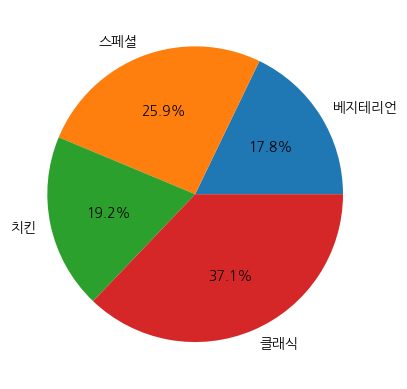

In [ ]:
plt.pie(quantity_by_category['quantity'],labels=quantity_by_category['category'],autopct='%.1f%%')
plt.show()

- 판매량 기준으로 보았을때, 클래식 > 스페셜 > 치킨 > 베지테리언 순인 것을 확인할 수 있다.

In [ ]:
# 피자 카테고리별 속한 피자 메뉴 수
pizza_orders_df.groupby('category',as_index=False)['pizza_name'].nunique().sort_values(by='pizza_name',ascending=False)

,category,pizza_name
1,스페셜,4
3,클래식,4
0,베지테리언,3
2,치킨,2


In [ ]:
# 피자 카테고리별 피자 메뉴별 총 판매량 집계
quantity_by_category = pizza_orders_df.groupby(['category','pizza_name'],as_index=False)['quantity'].sum()
quantity_by_category

,category,pizza_name,quantity
0,베지테리언,그린 가든 피자,2621
1,베지테리언,시금치 페스토 피자,2616
2,베지테리언,파이브 치즈 피자,3609
3,스페셜,불고기 피자,2115
4,스페셜,포테이토 피자,3291
5,스페셜,프로슈토 루꼴라 피자,1103
6,스페셜,하와이안 피자,6316
7,치킨,바비큐 치킨 피자,4065
8,치킨,타이 치킨 피자,5432
9,클래식,빅 미트 피자,4145


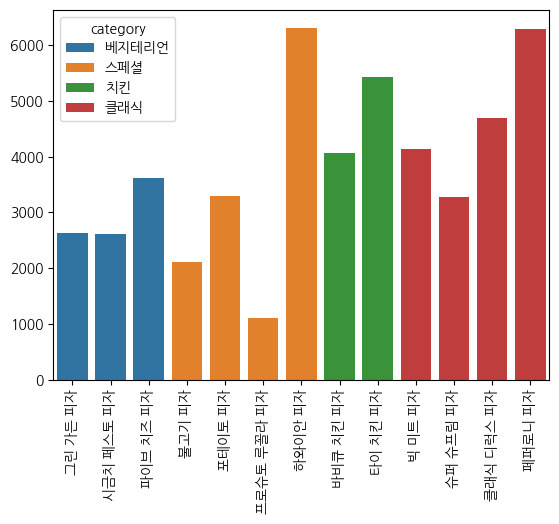

In [ ]:
sns.barplot(data=quantity_by_category, x='pizza_name',y='quantity',hue='category')
plt.xticks(rotation=90)
plt.title('')
plt.xlabel('')
plt.ylabel('')
plt.show()

- 클래식 카테고리 : 판매량 기준 1위, 페퍼로니 피자의 판매량이 가장 높고, 대체로 잘 팔린다.
- 스페셜 카테고리 : 판매량 기준 2위였지만, 사실상 하와이안 피자를 제외하면 판매량이 저조하다.
- 치킨 카테고리 : 판매량 기준 3위, 메뉴가 2개 뿐이지만 모두 잘 팔린다.
- 베지테리안 카테고리: 판매량 기준 4위, 다른 카테고리에 비해 판매량이 적고, 그나마 파이브치즈 피자가 채소 위주의 피자보다는 잘 팔린다.

### 각 피자 메뉴의 월별 판매량

In [ ]:
pizza_orders_df.head(1)

,order_id,order_timestamp,order_details_id,pizza_id,quantity,pizza_name,size,price,category,ingredients,sales,month,day_name,dayofweek,hour,type_of_day
0,1,2023-01-01 11:45:11,1,hawaiian_m,1,하와이안 피자,M,21800,스페셜,"토마토, 베이컨, 파인애플, 모짜렐라 치즈",21800,1,Sunday,6,11,주말


In [ ]:
# 피자 메뉴별 월별 총 판매량
quantity_by_pozza_month = pizza_orders_df.groupby(['pizza_name','month'],as_index=False)['quantity'].sum()
quantity_by_pozza_month

,pizza_name,month,quantity
0,그린 가든 피자,1,222
1,그린 가든 피자,2,212
2,그린 가든 피자,3,267
3,그린 가든 피자,4,209
4,그린 가든 피자,5,233
...,...,...,...
151,하와이안 피자,8,538
152,하와이안 피자,9,498
153,하와이안 피자,10,473
154,하와이안 피자,11,533


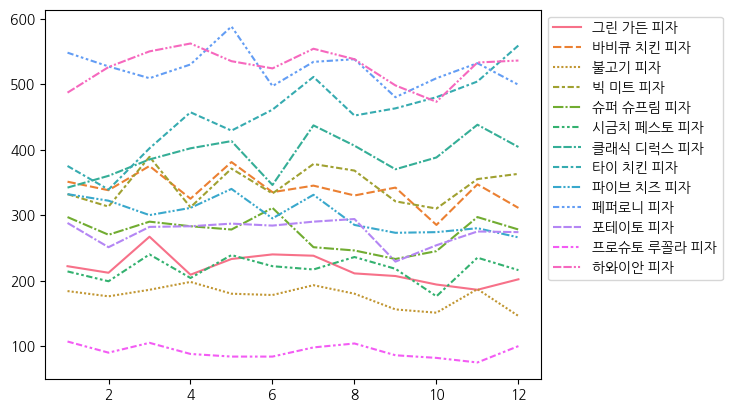

In [ ]:
sns.lineplot(data=quantity_by_pozza_month,x='month',y='quantity',hue='pizza_name',style='pizza_name')
plt.legend(bbox_to_anchor=(1,1))
plt.title('')
plt.xlabel('')
plt.ylabel('')
plt.show()

- 하와이안,페퍼로니는 꾸준히 상위권을 차지한다.
- 프로슈토 루꼴라 피자의 판매량이 낮다.
- 타이 치킨 피자는 1년동안 판매량이 꾸준히 상승하여 12월에는 가장 많이 팔린 메뉴가 되었다. 따라서 판매량이 꾸준히 상승한 이유를 파악해 두면 앞으로 메뉴 개발 관리에 도움이 될 것이다.

### 각 피자 메뉴의 사이즈별 판매량

In [ ]:
pizza_orders_df.head(1)

,order_id,order_timestamp,order_details_id,pizza_id,quantity,pizza_name,size,price,category,ingredients,sales,month,day_name,dayofweek,hour,type_of_day
0,1,2023-01-01 11:45:11,1,hawaiian_m,1,하와이안 피자,M,21800,스페셜,"토마토, 베이컨, 파인애플, 모짜렐라 치즈",21800,1,Sunday,6,11,주말


In [ ]:
# 사이즈 칼럼 순서가 있는 범주형
pizza_orders_df['size'] = pd.Categorical(pizza_orders_df['size'], ordered=True, categories=['S','M','L'])

In [ ]:
quantity_by_size = pizza_orders_df.groupby(['pizza_name','size'],as_index=False)['quantity'].sum()
quantity_by_size

/tmp/ipykernel_1958/2027455342.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  quantity_by_size = pizza_orders_df.groupby(['pizza_name','size'],as_index=False)['quantity'].sum()


,pizza_name,size,quantity
0,그린 가든 피자,S,991
1,그린 가든 피자,M,884
2,그린 가든 피자,L,746
3,바비큐 치킨 피자,S,863
4,바비큐 치킨 피자,M,1528
5,바비큐 치킨 피자,L,1674
6,불고기 피자,S,564
7,불고기 피자,M,691
8,불고기 피자,L,860
9,빅 미트 피자,S,2471


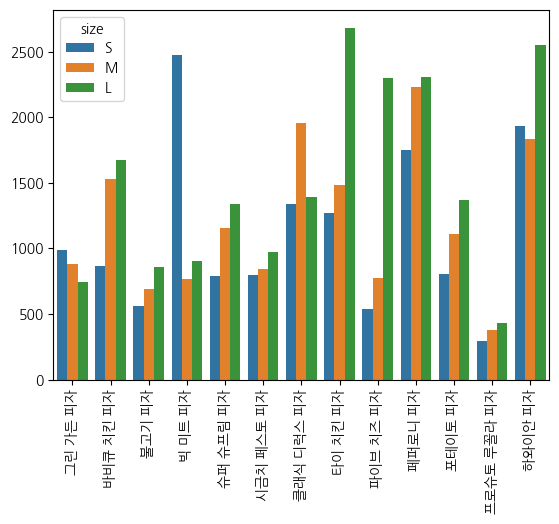

In [ ]:
sns.barplot(data=quantity_by_size,x='pizza_name',y='quantity',hue='size')

plt.xticks(rotation=90)

plt.title('')
plt.xlabel('')
plt.ylabel('')
plt.show()

In [ ]:
- 총 13가지 피자 메뉴 중 10가지 메뉴에서 L사이즈의 판매량이 가장 많은 것으로 보아 대체로 L사이즈 피자의 인기가 가장 많다.
- M 사이즈 판매량이 가장 많은 피자는 클래식 뿐이다
- S 사이즈 판매량이 가장 많은 피자는 그린, 빅 미트
- 빅미트는 혼자, 타이 치킨과 하와이안 피자는 가족단위 주문?